# CONUS Great Plain domain forecast checks

In [1]:
import os
import sys
import yaml
import argparse
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
sys.path.insert(0, os.path.realpath('./libs/'))
import plevel_utils as pu

In [3]:
from scipy.ndimage import uniform_filter

In [4]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch

import matplotlib.gridspec as gridspec

from matplotlib.lines import Line2D
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [5]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [83]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

## Prep data

In [8]:
GRAVITY = 9.80665

ds_static = xr.open_zarr('/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/static/C404_TC_static_8km.zarr')
lat = ds_static['XLAT'].values
lon = ds_static['XLONG'].values

# 2022, "AL092022", "Ian", 5, "2022-09-27 00:00", "2022-09-30 18:05"

year = 2022
varnames = ['WRF_P', 'WRF_Q_tot_05', 'WRF_T', 'WRF_U', 'WRF_V',]
varnames_all = ['WRF_P', 'WRF_T', 'WRF_U', 'WRF_V', 'WRF_Q_tot', 'WRF_MSLP', 'WRF_PWAT', 'WRF_SP', 'WRF_T2', 'WRF_U10', 'WRF_V10', 'WRF_precip']

# fn_unet = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_UNET/TC_UNET_pred_{year}_MSLP.zarr'
# ds_unet = xr.open_zarr(fn_unet).sel(time=slice('2022-09-27', '2022-09-30'))
# ds_unet_slice = ds_unet.isel(time=ind_pick)

# ============================= #
# GDAS
# ============================= #
fn_pred = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_ERA5_{year}.zarr'
ds_pred = xr.open_zarr(fn_pred).sel(time=slice('2022-09-27', '2022-09-30'))[varnames]
ds_pred['WRF_Q_tot'] = ds_pred['WRF_Q_tot_05']**2
ds_pred = ds_pred.drop_vars(['WRF_Q_tot_05',])
fn_corrdiff = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_ERA5_corrdiff_pred_{year}_mem01.zarr'
ds_corrdiff = xr.open_zarr(fn_corrdiff).sel(time=slice('2022-09-27', '2022-09-30'))
ds_pred_ERA5 = xr.merge([ds_pred, ds_corrdiff])
ds_pred_ERA5['WRF_SPD10'] = np.sqrt(ds_pred_ERA5['WRF_V10']**2 + ds_pred_ERA5['WRF_U10']**2)

# ============================= #
# GDAS
# ============================= #
fn_pred = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_GDAS_{year}.zarr'
ds_pred = xr.open_zarr(fn_pred).sel(time=slice('2022-09-27', '2022-09-30'))[varnames]
ds_pred['WRF_Q_tot'] = ds_pred['WRF_Q_tot_05']**2
ds_pred = ds_pred.drop_vars(['WRF_Q_tot_05',])
fn_corrdiff = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_GDAS_corrdiff_pred_{year}_mem01.zarr'
ds_corrdiff = xr.open_zarr(fn_corrdiff).sel(time=slice('2022-09-27', '2022-09-30'))
ds_pred_GDAS = xr.merge([ds_pred, ds_corrdiff])
ds_pred_GDAS['WRF_SPD10'] = np.sqrt(ds_pred_GDAS['WRF_V10']**2 + ds_pred_GDAS['WRF_U10']**2)

# ============================= #
# target
# ============================= #
fn_target = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/C404_8km/C404_8km_{year}.zarr'
ds_target = xr.open_zarr(fn_target).sel(time=slice('2022-09-27', '2022-09-30'))


# ---------------- #
# MSLP derive (x)
surf_gp = ds_static["HGT_M"].values * GRAVITY
    
# pull the time-varying 2D fields (this triggers dask compute)
sp  = ds_target["WRF_SP"].values
t2m = ds_target["WRF_T2"].values

mslp = np.zeros_like(sp, dtype=np.float32)
for t in range(sp.shape[0]):
    mslp[t] = pu.mean_sea_level_pressure_simple(sp[t], t2m[t], surf_gp,)

# Wrap back into xarray
mslp_da = xr.DataArray(
    mslp,
    dims=("time", "south_north", "west_east"),
    coords={
        "time": ds_target["time"],
        "south_north": ds_target["south_north"],
        "west_east": ds_target["west_east"],
    },
    name="MSLP",
    attrs={"units": "Pa", "long_name": "Mean sea level pressure"},
)

ds_target["WRF_MSLP"] = mslp_da
# ---------------- #
ds_target = ds_target[varnames_all]
ds_target['WRF_SPD10'] = np.sqrt(ds_target['WRF_V10']**2 + ds_target['WRF_U10']**2)

### Case 1: Intensification

In [44]:
ind_pick = 36 
ds_target_slice1 = ds_target.isel(time=ind_pick)
ds_ERA5_slice1 = ds_pred_ERA5.isel(time=ind_pick)
ds_GDAS_slice1 = ds_pred_GDAS.isel(time=ind_pick)

dict_PLOT1 = {}
dict_PLOT1['target_spd'] = ds_target_slice1['WRF_SPD10'].values
dict_PLOT1['target_u10'] = ds_target_slice1['WRF_U10'].values
dict_PLOT1['target_v10'] = ds_target_slice1['WRF_V10'].values
dict_PLOT1['target_tp'] = ds_target_slice1['WRF_precip'].values
dict_PLOT1['target_pwat'] = ds_target_slice1['WRF_PWAT'].values

dict_PLOT1['ERA5_spd'] = ds_ERA5_slice1['WRF_SPD10'].values
dict_PLOT1['ERA5_u10'] = ds_ERA5_slice1['WRF_U10'].values
dict_PLOT1['ERA5_v10'] = ds_ERA5_slice1['WRF_V10'].values
dict_PLOT1['ERA5_tp'] = ds_ERA5_slice1['WRF_precip'].values
dict_PLOT1['ERA5_pwat'] = ds_ERA5_slice1['WRF_PWAT'].values

dict_PLOT1['GDAS_spd'] = ds_GDAS_slice1['WRF_SPD10'].values
dict_PLOT1['GDAS_u10'] = ds_GDAS_slice1['WRF_U10'].values
dict_PLOT1['GDAS_v10'] = ds_GDAS_slice1['WRF_V10'].values
dict_PLOT1['GDAS_tp'] = ds_GDAS_slice1['WRF_precip'].values
dict_PLOT1['GDAS_pwat'] = ds_GDAS_slice1['WRF_PWAT'].values

### Case 2: Final landing

In [45]:
ind_pick = 90
ds_target_slice2 = ds_target.isel(time=ind_pick)
ds_ERA5_slice2 = ds_pred_ERA5.isel(time=ind_pick)
ds_GDAS_slice2 = ds_pred_GDAS.isel(time=ind_pick)

dict_PLOT2 = {}
dict_PLOT2['target_spd'] = ds_target_slice2['WRF_SPD10'].values
dict_PLOT2['target_u10'] = ds_target_slice2['WRF_U10'].values
dict_PLOT2['target_v10'] = ds_target_slice2['WRF_V10'].values
dict_PLOT2['target_tp'] = ds_target_slice2['WRF_precip'].values
dict_PLOT2['target_pwat'] = ds_target_slice2['WRF_PWAT'].values

dict_PLOT2['ERA5_spd'] = ds_ERA5_slice2['WRF_SPD10'].values
dict_PLOT2['ERA5_u10'] = ds_ERA5_slice2['WRF_U10'].values
dict_PLOT2['ERA5_v10'] = ds_ERA5_slice2['WRF_V10'].values
dict_PLOT2['ERA5_tp'] = ds_ERA5_slice2['WRF_precip'].values
dict_PLOT2['ERA5_pwat'] = ds_ERA5_slice2['WRF_PWAT'].values

dict_PLOT2['GDAS_spd'] = ds_GDAS_slice2['WRF_SPD10'].values
dict_PLOT2['GDAS_u10'] = ds_GDAS_slice2['WRF_U10'].values
dict_PLOT2['GDAS_v10'] = ds_GDAS_slice2['WRF_V10'].values
dict_PLOT2['GDAS_tp'] = ds_GDAS_slice2['WRF_precip'].values
dict_PLOT2['GDAS_pwat'] = ds_GDAS_slice2['WRF_PWAT'].values

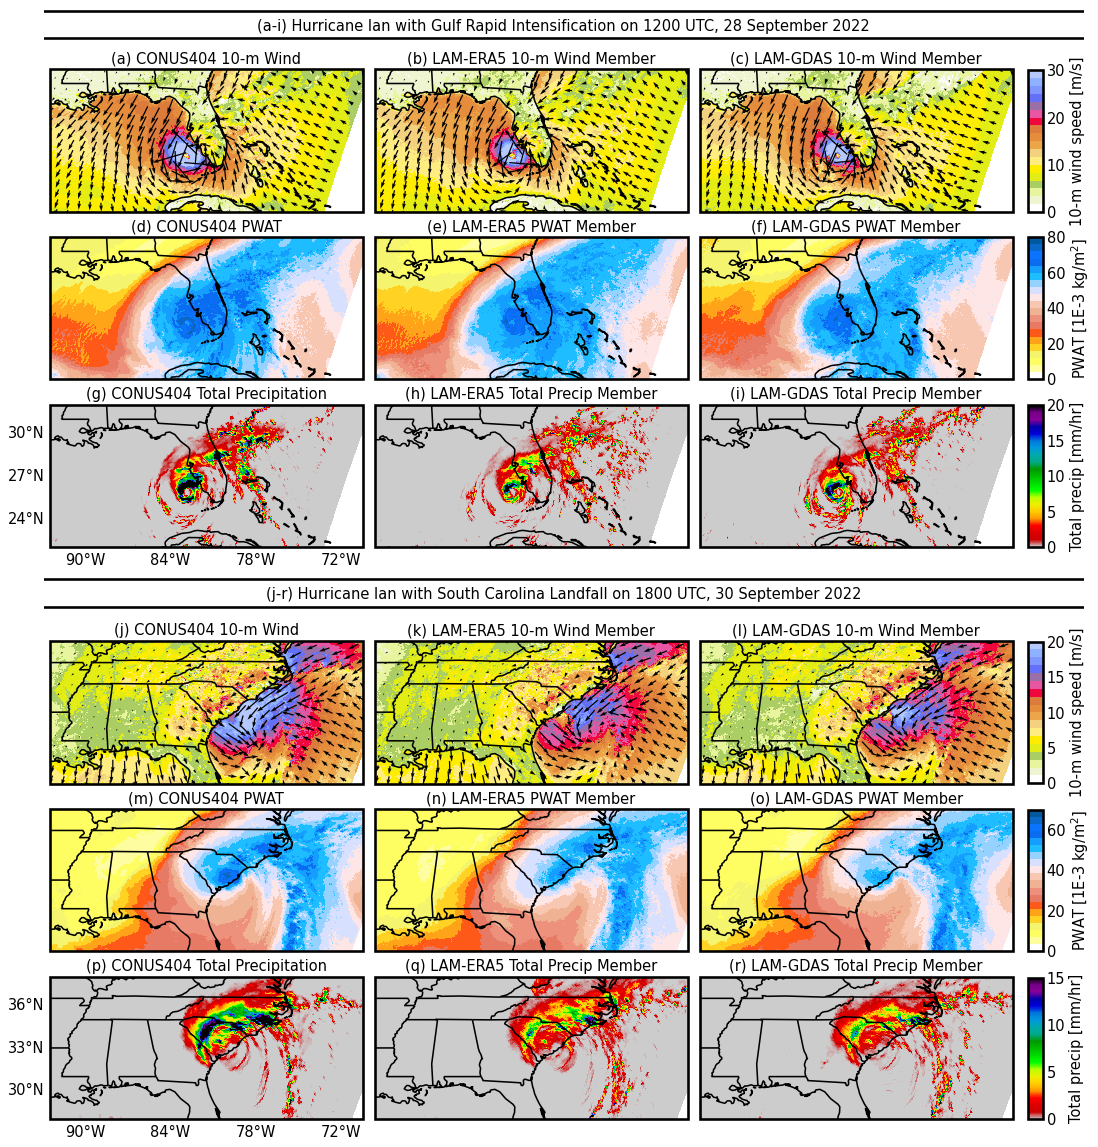

In [84]:
scale_param = '50m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param), edgecolor='k', linewidth=1.5, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

skip = slice(None, None, 10)

LIM_pwat1 = [0, 80]
LIM_spd1 = [0, 30]
LIM_precip1 = [0, 20]

LIM_pwat2 = [0, 70]
LIM_spd2 = [0, 20]
LIM_precip2 = [0, 15]

cmap_pwat = cmaps.rh_19lev #t2m_29lev
cmap_spd = cmaps.wind_17lev
cmap_precip = plt.cm.nipy_spectral_r
# gu.precip_cmap(return_rgb=True, land_map=False)

proj_ = ccrs.PlateCarree() #ccrs.LambertConformal(central_longitude=-83, central_latitude=35, standard_parallels=(20, 40))
proj_grid = ccrs.PlateCarree()


fig = plt.figure(figsize=(13, 14), dpi=dpi_)
gs = gridspec.GridSpec(7, 3, height_ratios=[1, 1, 1, 0.3, 1, 1, 1], width_ratios=[1,]*3)

AX_maps1 = []
AX_maps1.append(plt.subplot(gs[0, 0], projection=proj_))
AX_maps1.append(plt.subplot(gs[0, 1], projection=proj_))
AX_maps1.append(plt.subplot(gs[0, 2], projection=proj_))
AX_maps1.append(plt.subplot(gs[1, 0], projection=proj_))
AX_maps1.append(plt.subplot(gs[1, 1], projection=proj_))
AX_maps1.append(plt.subplot(gs[1, 2], projection=proj_))
AX_maps1.append(plt.subplot(gs[2, 0], projection=proj_))
AX_maps1.append(plt.subplot(gs[2, 1], projection=proj_))
AX_maps1.append(plt.subplot(gs[2, 2], projection=proj_))

AX_maps2 = []
AX_maps2.append(plt.subplot(gs[4, 0], projection=proj_))
AX_maps2.append(plt.subplot(gs[4, 1], projection=proj_))
AX_maps2.append(plt.subplot(gs[4, 2], projection=proj_))
AX_maps2.append(plt.subplot(gs[5, 0], projection=proj_))
AX_maps2.append(plt.subplot(gs[5, 1], projection=proj_))
AX_maps2.append(plt.subplot(gs[5, 2], projection=proj_))
AX_maps2.append(plt.subplot(gs[6, 0], projection=proj_))
AX_maps2.append(plt.subplot(gs[6, 1], projection=proj_))
AX_maps2.append(plt.subplot(gs[6, 2], projection=proj_))

plt.subplots_adjust(0, 0, 1, 1, hspace=0.2, wspace=0.0)


map_extent = [-92.5, -70.5, 22, 32]
for ax_map in AX_maps1:
    ax_map.set_extent(map_extent, crs=proj_grid)
    ax_map = map_gridline_opt(ax_map)

i_ax = 6
ax = AX_maps1[i_ax]
    
GL1 = ax.gridlines(
    crs=ccrs.PlateCarree(), 
    draw_labels=True, x_inline=False, y_inline=False, 
    color=None, linewidth=0, zorder=5
)

GL1.xlocator = ticker.FixedLocator([-90, -84, -78, -72])
GL1.ylocator = ticker.FixedLocator([24, 27, 30])

map_extent = [-92.5, -70.5, 22+6, 32+6]
for ax_map in AX_maps2:
    ax_map.set_extent(map_extent, crs=proj_grid)
    ax_map = map_gridline_opt(ax_map)

i_ax = 6
ax = AX_maps2[i_ax]
    
GL2 = ax.gridlines(
    crs=ccrs.PlateCarree(), 
    draw_labels=True, x_inline=False, y_inline=False, 
    color=None, linewidth=0, zorder=5
)

GL2.xlocator = ticker.FixedLocator([-90, -84, -78, -72])
GL2.ylocator = ticker.FixedLocator([30, 33, 36])

for GL in [GL1, GL2]:
    GL.xlabel_style = {'size': 14}
    GL.ylabel_style = {'size': 14}
    
    GL.top_labels = None
    GL.right_labels = None
    GL.rotate_labels = False

#GL1.bottom_labels = None

AX_maps1[0].set_title('(a) CONUS404 10-m Wind', fontsize=14)
AX_maps1[1].set_title('(b) LAM-ERA5 10-m Wind Member', fontsize=14)
AX_maps1[2].set_title('(c) LAM-GDAS 10-m Wind Member', fontsize=14)

AX_maps1[3].set_title('(d) CONUS404 PWAT', fontsize=14)
AX_maps1[4].set_title('(e) LAM-ERA5 PWAT Member', fontsize=14)
AX_maps1[5].set_title('(f) LAM-GDAS PWAT Member', fontsize=14)

AX_maps1[6].set_title('(g) CONUS404 Total Precipitation', fontsize=14)
AX_maps1[7].set_title('(h) LAM-ERA5 Total Precip Member', fontsize=14)
AX_maps1[8].set_title('(i) LAM-GDAS Total Precip Member', fontsize=14)

AX_maps2[0].set_title('(j) CONUS404 10-m Wind', fontsize=14)
AX_maps2[1].set_title('(k) LAM-ERA5 10-m Wind Member', fontsize=14)
AX_maps2[2].set_title('(l) LAM-GDAS 10-m Wind Member', fontsize=14)

AX_maps2[3].set_title('(m) CONUS404 PWAT', fontsize=14)
AX_maps2[4].set_title('(n) LAM-ERA5 PWAT Member', fontsize=14)
AX_maps2[5].set_title('(o) LAM-GDAS PWAT Member', fontsize=14)

AX_maps2[6].set_title('(p) CONUS404 Total Precipitation', fontsize=14)
AX_maps2[7].set_title('(q) LAM-ERA5 Total Precip Member', fontsize=14)
AX_maps2[8].set_title('(r) LAM-GDAS Total Precip Member', fontsize=14)


for i_ax, name in enumerate(['target', 'ERA5', 'GDAS']):
    CS11 = AX_maps1[i_ax].pcolormesh(lon, lat, dict_PLOT1[f'{name}_spd'], vmin=LIM_spd1[0], vmax=LIM_spd1[1], cmap=cmap_spd, transform=proj_)
    
    AX_maps1[i_ax].quiver(
        lon[skip, skip], lat[skip, skip], 
        dict_PLOT1[f'{name}_u10'][skip, skip], dict_PLOT1[f'{name}_v10'][skip, skip],
        color='k', width=0.004, scale=300, transform=proj_
    )
    
    # precip
    CS12 = AX_maps1[i_ax+3].pcolormesh(lon, lat, 1e3*dict_PLOT1[f'{name}_pwat'], vmin=LIM_pwat1[0], vmax=LIM_pwat1[1], cmap=cmap_pwat, transform=proj_)
    CS13 = AX_maps1[i_ax+6].pcolormesh(lon, lat, dict_PLOT1[f'{name}_tp'], vmin=LIM_precip1[0], vmax=LIM_precip1[1], cmap=cmap_precip, transform=proj_)



for i_ax, name in enumerate(['target', 'ERA5', 'GDAS']):
    CS21 = AX_maps2[i_ax].pcolormesh(lon, lat, dict_PLOT2[f'{name}_spd'], vmin=LIM_spd2[0], vmax=LIM_spd2[1], cmap=cmap_spd, transform=proj_)
    
    AX_maps2[i_ax].quiver(
        lon[skip, skip], lat[skip, skip], 
        dict_PLOT2[f'{name}_u10'][skip, skip], dict_PLOT1[f'{name}_v10'][skip, skip],
        color='k', width=0.004, scale=300, transform=proj_
    )
    
    # precip
    CS22 = AX_maps2[i_ax+3].pcolormesh(lon, lat, 1e3*dict_PLOT2[f'{name}_pwat'], vmin=LIM_pwat2[0], vmax=LIM_pwat2[1], cmap=cmap_pwat, transform=proj_)
    CS23 = AX_maps2[i_ax+6].pcolormesh(lon, lat, dict_PLOT2[f'{name}_tp'], vmin=LIM_precip2[0], vmax=LIM_precip2[1], cmap=cmap_precip, transform=proj_)

# 
ax_base11 = fig.add_axes([1.01, 0.864, 0.05, 0.135])
ax_base11.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax11 = inset_axes(ax_base11, height='100%', width='30%', borderpad=0, loc=2)
CBar11 = plt.colorbar(CS11, orientation='vertical', cax=cax11)
CBar11.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar11.outline.set_linewidth(2.5)
CBar11.ax.set_ylabel('10-m wind speed [m/s]', fontsize=14)

ax_base12 = fig.add_axes([1.01, 0.705, 0.05, 0.135])
ax_base12.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax12 = inset_axes(ax_base12, height='100%', width='30%', borderpad=0, loc=2)
CBar12 = plt.colorbar(CS12, orientation='vertical', cax=cax12)
CBar12.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar12.outline.set_linewidth(2.5)
CBar12.ax.set_ylabel('PWAT [1E-3 kg/m$\mathsf{^2}$]', fontsize=14)
#
ax_base13 = fig.add_axes([1.01, 0.545, 0.05, 0.135])
ax_base13.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax13 = inset_axes(ax_base13, height='100%', width='30%', borderpad=0, loc=2)
CBar13 = plt.colorbar(CS13, orientation='vertical', cax=cax13)
CBar13.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar13.outline.set_linewidth(2.5)
CBar13.ax.set_ylabel('Total precip [mm/hr]', fontsize=14)

# cs21: 10-m wind (block 2, top row)
ax_base21 = fig.add_axes([1.01, 0.320, 0.05, 0.135])
ax_base21.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax21 = inset_axes(ax_base21, height='100%', width='30%', borderpad=0, loc=2)
CBar21 = plt.colorbar(CS21, orientation='vertical', cax=cax21)
CBar21.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar21.outline.set_linewidth(2.5)
CBar21.ax.set_ylabel('10-m wind speed [m/s]', fontsize=14)

# cs22: pwat (block 2, middle row)
ax_base22 = fig.add_axes([1.01, 0.160, 0.05, 0.135])
ax_base22.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax22 = inset_axes(ax_base22, height='100%', width='30%', borderpad=0, loc=2)
CBar22 = plt.colorbar(CS22, orientation='vertical', cax=cax22)
CBar22.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar22.outline.set_linewidth(2.5)
CBar22.ax.set_ylabel('PWAT [1E-3 kg/m$\mathsf{^2}$]', fontsize=14)

# cs23: total precipitation (block 2, bottom row)
ax_base23 = fig.add_axes([1.01, 0.000, 0.05, 0.135])
ax_base23.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax23 = inset_axes(ax_base23, height='100%', width='30%', borderpad=0, loc=2)
CBar23 = plt.colorbar(CS23, orientation='vertical', cax=cax23)
CBar23.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar23.outline.set_linewidth(2.5)
CBar23.ax.set_ylabel('Total precip [mm/hr]', fontsize=14)

ax_txt1 = fig.add_axes([0.0, 1.0265, 1.067, 0.0325])
ax_txt1.text(
    0.5, 0.45,
    '(a-i) Hurricane Ian with Gulf Rapid Intensification on 1200 UTC, 28 September 2022',
    fontsize=14, va='center', ha='center', transform=ax_txt1.transAxes)
ax_txt1.axhline(0.9, xmin=0, xmax=1.0, color='k', linewidth=2.5)
ax_txt1.axhline(0.1, xmin=0, xmax=1.0, color='k', linewidth=2.5)

# 2022-09-30T18:00:00
ax_txt2 = fig.add_axes([0.0, 0.485, 1.067, 0.0325])
ax_txt2.text(
    0.5, 0.45,
    '(j-r) Hurricane Ian with South Carolina Landfall on 1800 UTC, 30 September 2022',
    fontsize=14, va='center', ha='center', transform=ax_txt2.transAxes)
ax_txt2.axhline(0.9, xmin=0, xmax=1.0, color='k', linewidth=2.5)
ax_txt2.axhline(0.1, xmin=0, xmax=1.0, color='k', linewidth=2.5)

ax_txt1.set_axis_off()
ax_txt2.set_axis_off()
ax_base11.set_axis_off()
ax_base12.set_axis_off()
ax_base13.set_axis_off()
ax_base21.set_axis_off()
ax_base22.set_axis_off()
ax_base23.set_axis_off()